***This is where we import the necerssary packages for our analysis***

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

### **CSV FILES**

Here, we read the CSV files generated after our API scrape. We assign them each to a variable.

In [41]:
gas_prices = pd.read_csv("../data/raw/gas_prices.csv")
crude_oil = pd.read_csv("../data/raw/crude_oil.csv")
national_prices = pd.read_csv("../data/raw/national_prices.csv")
inflation = pd.read_csv("../data/raw/inflation.csv")

### **DATASET HEADS**

We check the heads for each CSV file, to make sure they have been read correctly, and also to begin our exploration of the data.

In [74]:
display(gas_prices.head())
display(crude_oil.head())
display(national_prices.head())
display(inflation.head())

,date,gas
0,2023-01,3.619417
1,2023-02,3.577216
2,2023-03,3.590371
3,2023-04,3.723905
4,2023-05,3.708110


,date,oil
0,1986-01,23.2680
1,1986-02,15.4025
2,1986-03,12.6975
3,1986-04,12.6250
4,1986-05,15.1180


,date,natural_gas
0,1990-08,1.2180
1,1990-09,1.2580
2,1990-10,1.3354
3,1990-11,1.3240
4,1990-12,1.3410


,date,inflation
0,2015-01,234.747
1,2015-02,235.342
2,2015-03,235.976
3,2015-04,236.222
4,2015-05,237.001


### **DATA INFO**

Now that the .head() function has been performed on all CSV files, we now check the info on each file.

In [ ]:
print(gas_prices.info())

<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype    
---  ------  --------------  -----    
 0   date    41 non-null     period[M]
 1   gas     41 non-null     float64  
dtypes: float64(1), period[M](1)
memory usage: 788.0 bytes
None
<class 'pandas.DataFrame'>
RangeIndex: 485 entries, 0 to 484
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype    
---  ------  --------------  -----    
 0   date    485 non-null    period[M]
 1   oil     485 non-null    float64  
dtypes: float64(1), period[M](1)
memory usage: 7.7 KB
None


In [54]:
crude_oil.info()

<class 'pandas.DataFrame'>
RangeIndex: 2107 entries, 0 to 2106
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2107 non-null   datetime64[us]
 1   oil     2107 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 33.1 KB


In [60]:
national_prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 1866 entries, 0 to 1865
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1866 non-null   datetime64[us]
 1   natural_gas  1860 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 29.3 KB


In [64]:
inflation.info()

<class 'pandas.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       136 non-null    datetime64[us]
 1   inflation  136 non-null    str           
dtypes: datetime64[us](1), str(1)
memory usage: 2.3 KB


### **DATA DESCRIBE**

Finally, we will now describe each dataset to get a sense of where values lie, their distribution, and the size of each dataset.

In [44]:
gas_prices.describe()

,value
count,4999.000000
mean,3.496251
std,0.666944
min,2.147000
25%,3.003000
50%,3.337000
75%,3.897000
max,6.129000


In [55]:
crude_oil.describe()

,date,oil
count,2107,2107.000000
mean,2006-03-10 00:00:00,48.416611
min,1986-01-03 00:00:00,3.320000
25%,1996-02-05 12:00:00,20.355000
50%,2006-03-10 00:00:00,43.500000
75%,2016-04-11 12:00:00,71.520000
max,2026-05-15 00:00:00,142.520000
std,NaN,29.486055


In [62]:
national_prices.describe()

,date,natural_gas
count,1866,1860.000000
mean,2008-07-03 12:00:00,2.265915
min,1990-08-20 00:00:00,0.907000
25%,1999-07-27 18:00:00,1.243750
50%,2008-07-03 12:00:00,2.275000
75%,2017-06-10 06:00:00,3.068250
max,2026-05-18 00:00:00,5.006000
std,NaN,0.957538


In [73]:
inflation.describe()

,date,inflation
count,136,136
unique,136,135
top,2015-01,255.802
freq,1,2


### **DATETIME**

It is necressary to organize the chronological information for each dataset into datetime, so that it is standardized and, therefore, easier to analyze and manipulate.

In [46]:
gas_prices['period'] = pd.to_datetime(gas_prices['period'])
crude_oil['period'] = pd.to_datetime(crude_oil['period'])
national_prices['period'] = pd.to_datetime(national_prices['period'])
inflation['date'] = pd.to_datetime(inflation['date'])

### **COLUMN ASSIGNMENT**

We are now reassigning the datasets to equivalent versions with predetermined columns. The first three now have the columns 'period' and 'value', while the fourth has the columns 'date' and 'value'.

In [47]:
gas_prices = gas_prices[['period', 'value']]
crude_oil = crude_oil[['period', 'value']]
national_prices = national_prices[['period', 'value']]
inflation = inflation[['date', 'value']]

### **FURTHER SIMPLIFICATION**

Now, we further simplfy the dataframes to focus on the data that is of interest to us.

In [75]:
gas_prices.columns = ['date', 'gas']
crude_oil.columns = ['date', 'oil']
national_prices.columns = ['date', 'natural_gas']
inflation.columns = ['date', 'inflation']

### The next four cells are simply to check that the date-time reformatting and column assignment were both successful for all four datasets.

In [ ]:
gas_prices['date']

0     2023-01
1     2023-02
2     2023-03
3     2023-04
4     2023-05
5     2023-06
6     2023-07
7     2023-08
8     2023-09
9     2023-10
10    2023-11
11    2023-12
12    2024-01
13    2024-02
14    2024-03
15    2024-04
16    2024-05
17    2024-06
18    2024-07
19    2024-08
20    2024-09
21    2024-10
22    2024-11
23    2024-12
24    2025-01
25    2025-02
26    2025-03
27    2025-04
28    2025-05
29    2025-06
30    2025-07
31    2025-08
32    2025-09
33    2025-10
34    2025-11
35    2025-12
36    2026-01
37    2026-02
38    2026-03
39    2026-04
40    2026-05
Name: date, dtype: period[M]

In [56]:
crude_oil['date']

0      2026-05-15
1      2026-05-08
2      2026-05-01
3      2026-04-24
4      2026-04-17
          ...    
2102   1986-01-31
2103   1986-01-24
2104   1986-01-17
2105   1986-01-10
2106   1986-01-03
Name: date, Length: 2107, dtype: datetime64[us]

In [57]:
national_prices['date']

0      1990-08-20
1      1990-08-27
2      1990-09-03
3      1990-09-10
4      1990-09-17
          ...    
1861   2026-04-20
1862   2026-04-27
1863   2026-05-04
1864   2026-05-11
1865   2026-05-18
Name: date, Length: 1866, dtype: datetime64[us]

In [58]:
inflation['date']

0     2015-01-01
1     2015-02-01
2     2015-03-01
3     2015-04-01
4     2015-05-01
         ...    
131   2025-12-01
132   2026-01-01
133   2026-02-01
134   2026-03-01
135   2026-04-01
Name: date, Length: 136, dtype: datetime64[us]

### **MERGE**

We now peform an inner merge on all four datasets, in preparation for analysis.

In [65]:
# Convert all dates into month-year only
gas_prices['date'] = gas_prices['date'].dt.to_period('M')
crude_oil['date'] = crude_oil['date'].dt.to_period('M')
national_prices['date'] = national_prices['date'].dt.to_period('M')
inflation['date'] = inflation['date'].dt.to_period('M')

# Now I have 4-5 of values in the same month. Average all rows inside each of those months
gas_prices = gas_prices.groupby('date')['gas'].mean().reset_index()
crude_oil = crude_oil.groupby('date')['oil'].mean().reset_index()
national_prices = national_prices.groupby("date")["natural_gas"].mean().reset_index()

df = gas_prices.merge(crude_oil,on="date")
df = df.merge(national_prices,on="date")
df = df.merge(inflation,on="date")

display(df.head())

,date,gas,oil,natural_gas,inflation
0,2023-01,3.619417,78.0100,3.33920,300.420
1,2023-02,3.577216,76.9875,3.38875,301.450
2,2023-03,3.590371,73.5140,3.42200,301.821
3,2023-04,3.723905,79.5050,3.60300,302.845
4,2023-05,3.708110,71.8575,3.55480,303.334


### **PLOT**

Now we plot the normalized datasets as a line graph. We are using low opacity, so that the lines are visible.

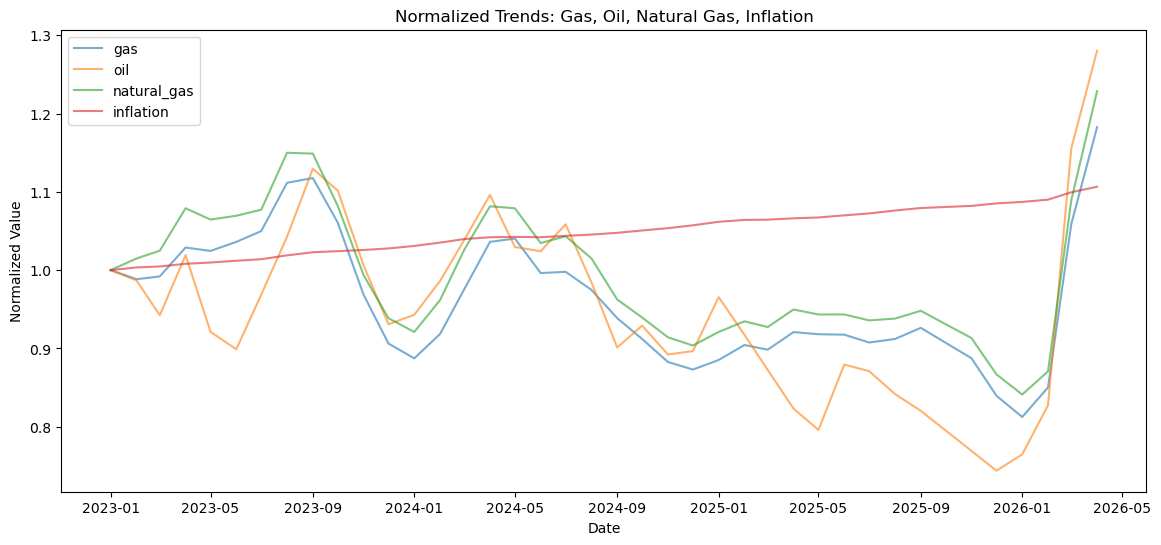

In [ ]:
# Convert date if needed
if str(df["date"].dtype) == "period[M]":
    df["date"] = df["date"].dt.to_timestamp

# Make numeric
cols = ["gas", "oil", "natural_gas", "inflation"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove missing values created during conversion
df = df.dropna()

# Create copy
scaled = df.copy()

# Normalize
for col in cols:
    scaled[col] = scaled[col] / scaled[col].iloc[0]

# Plot
plt.figure(figsize=(14,6))

for col in cols:
    plt.plot(
        scaled["date"],
        scaled[col],
        label=col,
        alpha=0.6
    )

plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.title("Normalized Trends: Gas, Oil, Natural Gas, Inflation")
plt.legend()

plt.show()

### **CORRELATION**

Now we calculate how each variable correlates with inflation.

We are calculating as follows: 

- 1 = strong positive relationship
- -1 = strong negative relationship
- 0 = weak relationship

In [77]:
corr = df.corr(numeric_only=True)

display(corr)

print(
    corr["inflation"]
    .sort_values(ascending=False)
)

,gas,oil,natural_gas,inflation
gas,1.000000,0.836643,0.994598,-0.382264
oil,0.836643,1.000000,0.849285,-0.267780
natural_gas,0.994598,0.849285,1.000000,-0.374279
inflation,-0.382264,-0.267780,-0.374279,1.000000


inflation      1.000000
oil           -0.267780
natural_gas   -0.374279
gas           -0.382264
Name: inflation, dtype: float64
